# Decoding Results Visualization
Load saved results and plot within-source and cross-source decoding for all z-score modes.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os

# Load saved results
results_path = r'N:\Experimental_Data\yujunchen\projects\AI_IAPS\Decoding\results\decoding_results_all_zmodes.pkl'
with open(results_path, 'rb') as f:
    all_results = pickle.load(f)

results_within_single = all_results['within_single']
results_within_avg = all_results['within_avg']
results_within_erp = all_results['within_erp']
results_cross_single = all_results['cross_single']
results_cross_avg = all_results['cross_avg']
results_cross_erp = all_results['cross_erp']
subs = all_results['subs']
roi_names = all_results['roi_names']
within_comparisons = all_results['within_comparisons']
cross_comparisons = all_results['cross_comparisons']
AVG_Z_MODES = all_results['AVG_Z_MODES']
SINGLE_Z_MODES = all_results['SINGLE_Z_MODES']

print(f"Subjects: {len(subs)}")
print(f"ROIs: {roi_names}")
print(f"AVG_Z_MODES: {AVG_Z_MODES}")
print(f"SINGLE_Z_MODES: {SINGLE_Z_MODES}")

Subjects: 30
ROIs: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'V3a', 'V3b', 'LO1', 'LO2', 'VO1', 'VO2', 'IPS', 'PHC1', 'PHC2']
AVG_Z_MODES: ['no_zscore', 'voxel_zscore', 'trial_zscore', 'voxel_trial_zscore', 'source_zscore', 'voxel_source_zscore', 'trial_voxel_zscore', 'trial_source_zscore', 'trial_voxel_source_zscore', 'voxel_trial_source_zscore']
SINGLE_Z_MODES: ['no_zscore', 'trial_zscore', 'source_zscore']


## Configuration

In [2]:
# Exclude Sub3 and Sub8
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]
n_subs = len(subs_plot)
print(f"Plotting {n_subs} subjects (excluded Sub3, Sub8)")

# --- Color scheme ---
# Within-source: blue for pleasant, orange/red for unpleasant; dark=Natural, light=AI
within_colors = {
    'pleasant_vs_neutral':       (0/255, 82/255, 155/255),
    'pleasantAI_vs_neutralAI':   (151/255, 179/255, 203/255),
    'unpleasant_vs_neutral':     (249/255, 118/255, 86/255),
    'unpleasantAI_vs_neutralAI': (250/255, 180/255, 166/255),
}

within_labels = {
    'pleasant_vs_neutral':       'PL vs Nt, Natural',
    'pleasantAI_vs_neutralAI':   'PL vs Nt, AI',
    'unpleasant_vs_neutral':     'UP vs Nt, Natural',
    'unpleasantAI_vs_neutralAI': 'UP vs Nt, AI',
}

# Cross-source: same color logic; dark=train-on-Natural, light=train-on-AI
cross_colors = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI':       (0/255, 82/255, 155/255),
    'train_pleasantAIvneutralAI_test_pleasantvneutral':       (151/255, 179/255, 203/255),
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI':   (249/255, 118/255, 86/255),
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral':   (250/255, 180/255, 166/255),
}

cross_labels = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI':       'PL vs Nt, trained on NA and tested on AI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral':       'PL vs Nt, trained on AI and tested on NA',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI':   'UP vs Nt, trained on NA and tested on AI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral':   'UP vs Nt, trained on AI and tested on NA',
}

within_order = ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI',
                'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']

cross_order = ['train_pleasantvneutral_test_pleasantAIvneutralAI',
               'train_pleasantAIvneutralAI_test_pleasantvneutral',
               'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
               'train_unpleasantAIvneutralAI_test_unpleasantvneutral']

Plotting 28 subjects (excluded Sub3, Sub8)


## Plotting Functions

In [3]:
def collect_data(result_dict, comp, z_mode, roi_names, subs_plot):
    """Collect n_subjects x n_rois array for a given comparison and z-mode."""
    return np.array([
        [result_dict[s][comp][z_mode].get(r, np.nan) for r in roi_names]
        for s in subs_plot
    ])


def collect_data_flat(result_dict, comp, roi_names, subs_plot):
    """Collect n_subjects x n_rois array for non-nested results (e.g. ERP)."""
    return np.array([
        [result_dict[s][comp].get(r, np.nan) for r in roi_names]
        for s in subs_plot
    ])


def plot_comparisons(result_dict, comp_order, color_dict, label_dict,
                     roi_names, subs_plot, title, z_mode=None, is_flat=False):
    """Plot grouped bar chart for 4 comparisons across ROIs."""
    n_comps = len(comp_order)
    n_rois = len(roi_names)
    n_subs = len(subs_plot)

    fig, ax = plt.subplots(figsize=(18, 7))
    bar_width = 0.18
    x = np.arange(n_rois)

    for ci, comp in enumerate(comp_order):
        if is_flat:
            data = collect_data_flat(result_dict, comp, roi_names, subs_plot)
        else:
            data = collect_data(result_dict, comp, z_mode, roi_names, subs_plot)

        means = np.nanmean(data, axis=0)
        sems = np.nanstd(data, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(data), axis=0))

        bars = ax.bar(x + ci * bar_width, means, bar_width, yerr=sems,
                      color=color_dict[comp], label=label_dict[comp],
                      capsize=3, edgecolor='black', linewidth=0.3, alpha=0.9)
        # Add value labels
        for bar in bars:
            h = bar.get_height()
            if not np.isnan(h):
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                        f'{h:.2f}', ha='center', va='bottom',
                        fontsize=8, rotation=90)

    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_xlabel('Region of Interest', fontsize=16)
    ax.set_ylabel('Accuracy (mean \u00b1 SEM)', fontsize=16)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.set_xticks(x + 1.5 * bar_width)
    ax.set_xticklabels(roi_names, fontsize=13, rotation=45, ha='right')
    ax.tick_params(axis='y', labelsize=13)
    ax.set_ylim([0.35, 0.90])
    ax.legend(fontsize=11, frameon=False, loc='upper right')
    plt.tight_layout()
    plt.show()

In [15]:
roi_names = all_results['roi_names']

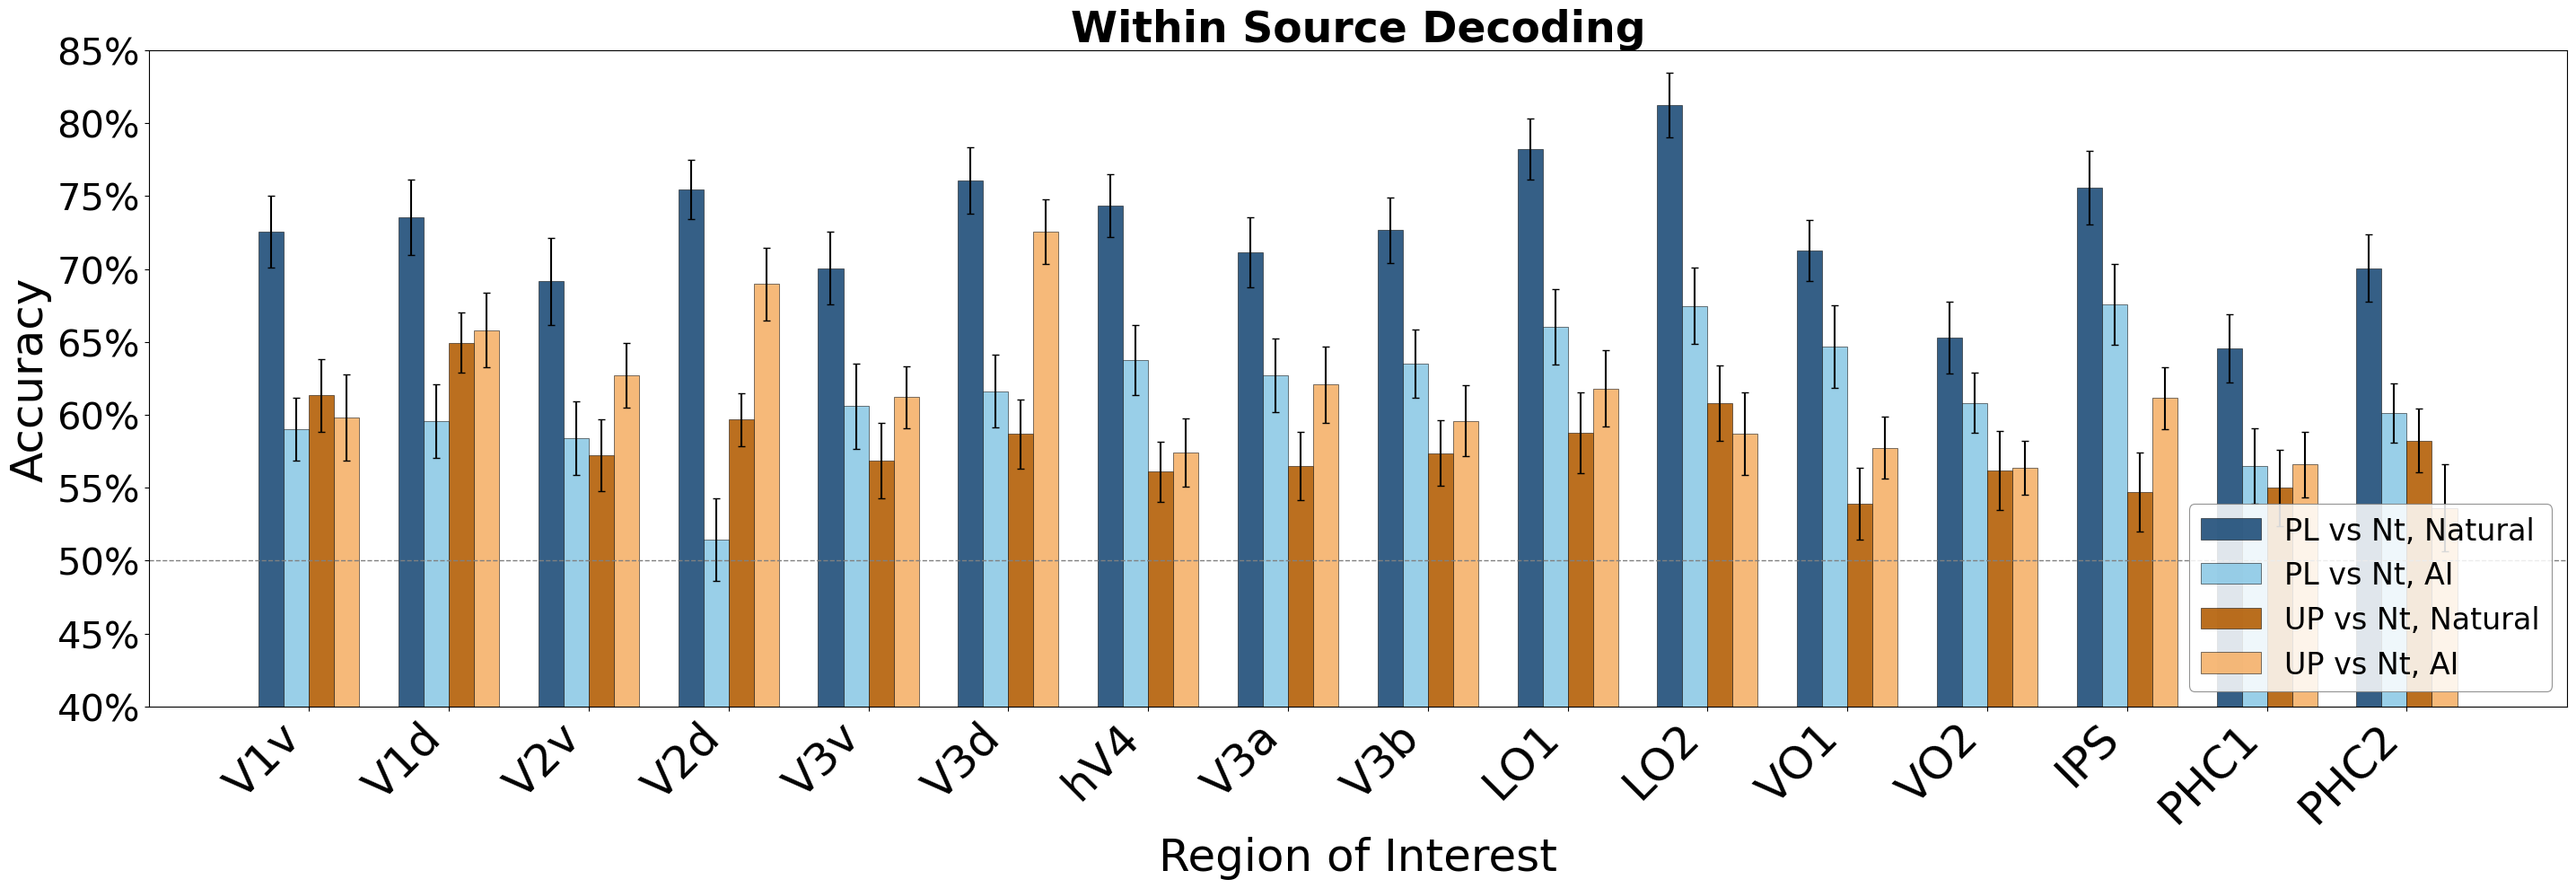

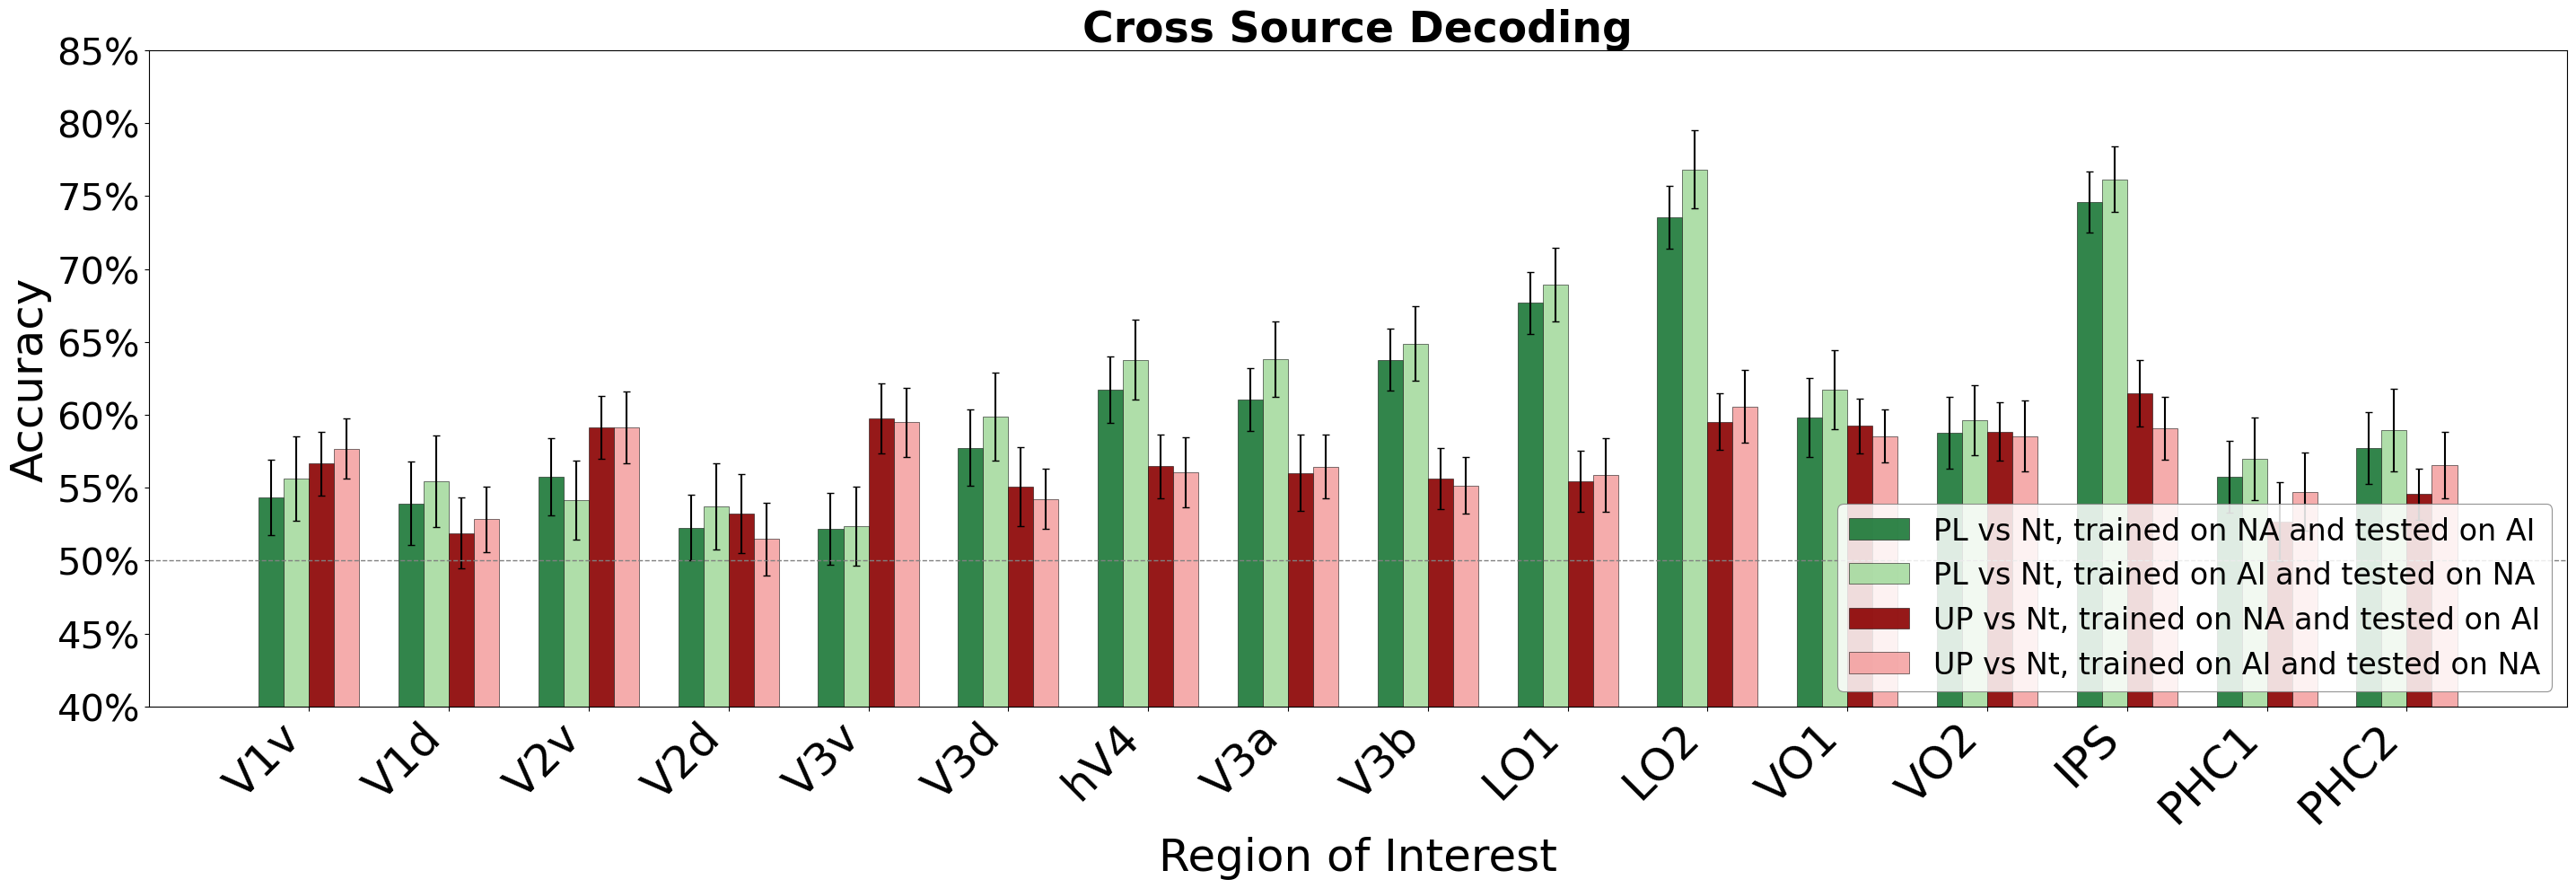

In [28]:
# ============================
# Subjects: remove Sub3, Sub8
# ============================
subs_plot = [s for s in subs if s not in ['Sub3', 'Sub8']]
roi_names = all_results['roi_names']

Z_MODE = 'voxel_trial_source_zscore'

within_colors = {
    'pleasant_vs_neutral': '#1f4e79',
    'pleasantAI_vs_neutralAI': '#8ecae6',
    'unpleasant_vs_neutral': '#b45f06',
    'unpleasantAI_vs_neutralAI': '#f6b26b'
}

cross_colors = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI': '#1b7837',
    'train_pleasantAIvneutralAI_test_pleasantvneutral': '#a6dba0',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': '#8b0000',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': '#f4a3a3'
}

within_labels = {
    'pleasant_vs_neutral':       'PL vs Nt, Natural',
    'pleasantAI_vs_neutralAI':   'PL vs Nt, AI',
    'unpleasant_vs_neutral':     'UP vs Nt, Natural',
    'unpleasantAI_vs_neutralAI': 'UP vs Nt, AI',
}

cross_labels = {
    'train_pleasantvneutral_test_pleasantAIvneutralAI':     'PL vs Nt, trained on NA and tested on AI',
    'train_pleasantAIvneutralAI_test_pleasantvneutral':     'PL vs Nt, trained on AI and tested on NA',
    'train_unpleasantvneutral_test_unpleasantAIvneutralAI': 'UP vs Nt, trained on NA and tested on AI',
    'train_unpleasantAIvneutralAI_test_unpleasantvneutral': 'UP vs Nt, trained on AI and tested on NA',
}

within_order = ['pleasant_vs_neutral', 'pleasantAI_vs_neutralAI',
                'unpleasant_vs_neutral', 'unpleasantAI_vs_neutralAI']

cross_order = ['train_pleasantvneutral_test_pleasantAIvneutralAI',
               'train_pleasantAIvneutralAI_test_pleasantvneutral',
               'train_unpleasantvneutral_test_unpleasantAIvneutralAI',
               'train_unpleasantAIvneutralAI_test_unpleasantvneutral']


def collect_avg_variant_data(comp, result_avg, z_mode):
    return np.array([
        [result_avg[s][comp][z_mode].get(r, np.nan) for r in roi_names]
        for s in subs_plot
    ])


import matplotlib.ticker as mticker

# ============================
# Within-Source
# ============================
fig, ax = plt.subplots(1, 1, figsize=(max(18, len(roi_names) * 1.8), 10))
x = np.arange(len(roi_names))
width = 0.18
n_c = len(within_order)

for ci, comp in enumerate(within_order):
    md = collect_avg_variant_data(comp, results_within_avg, Z_MODE)
    means = np.nanmean(md, axis=0)
    sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))
    offset = (ci - (n_c - 1) / 2) * width

    bars = ax.bar(
        x + offset, means, width, yerr=sems,
        color=within_colors[comp], label=within_labels[comp],
        capsize=3, alpha=0.9, edgecolor='black', linewidth=0.4
    )

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Accuracy', fontsize=36)
ax.set_xlabel('Region of Interest', fontsize=36)
ax.set_title('Within Source Decoding', fontsize=34, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.tick_params(axis='y', labelsize=30)
ax.set_xticks(x)
ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=36)
ax.set_ylim([0.40, 0.85])
legend = ax.legend(fontsize=24, loc='lower right', frameon=True,
                   facecolor='white', framealpha=0.85, edgecolor='gray')
legend.get_frame().set_linewidth(0.8)
plt.tight_layout()
plt.show()


# ============================
# Cross-Source
# ============================
fig, ax = plt.subplots(1, 1, figsize=(max(18, len(roi_names) * 1.8), 10))
x = np.arange(len(roi_names))
width = 0.18
n_c = len(cross_order)

for ci, comp in enumerate(cross_order):
    md = collect_avg_variant_data(comp, results_cross_avg, Z_MODE)
    means = np.nanmean(md, axis=0)
    sems = np.nanstd(md, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(md), axis=0))
    offset = (ci - (n_c - 1) / 2) * width

    bars = ax.bar(
        x + offset, means, width, yerr=sems,
        color=cross_colors[comp], label=cross_labels[comp],
        capsize=3, alpha=0.9, edgecolor='black', linewidth=0.4
    )

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel('Accuracy', fontsize=36)
ax.set_xlabel('Region of Interest', fontsize=36)
ax.set_title('Cross Source Decoding', fontsize=34, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
ax.tick_params(axis='y', labelsize=30)
ax.set_xticks(x)
ax.set_xticklabels(roi_names, rotation=45, ha='right', fontsize=36)
ax.set_ylim([0.40, 0.85])
legend = ax.legend(fontsize=24, loc='lower right', frameon=True,
                   facecolor='white', framealpha=0.85, edgecolor='gray')
legend.get_frame().set_linewidth(0.8)
plt.tight_layout()
plt.show()